In [6]:
import numpy as np

from plot_util import plot_matrices

# P1.3.4

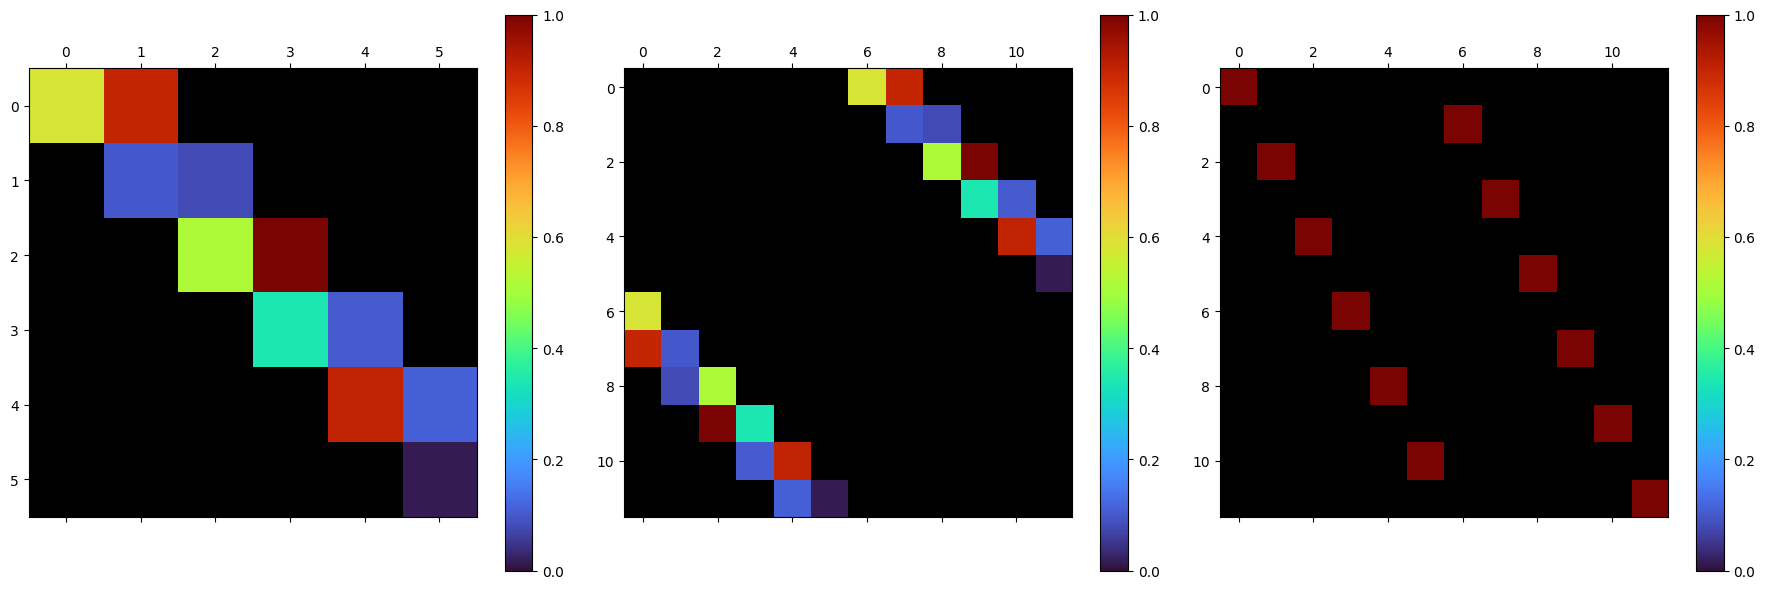

In [7]:
n = 6

# Initialize B, A, P
B = np.triu(np.tril(np.random.rand(n, n), 1))
A = np.zeros((2 * n, 2 * n))
A[:n,n:] = B
A[n:,:n] = B.T
I = np.eye(2 * n)
P = np.empty((2 * n, 2 * n))
P[0:2*n:2,:] = I[:n]
P[1:2*n:2,:] = I[n:]

plot_matrices([B, A, P], (1, 3), (18, 6))

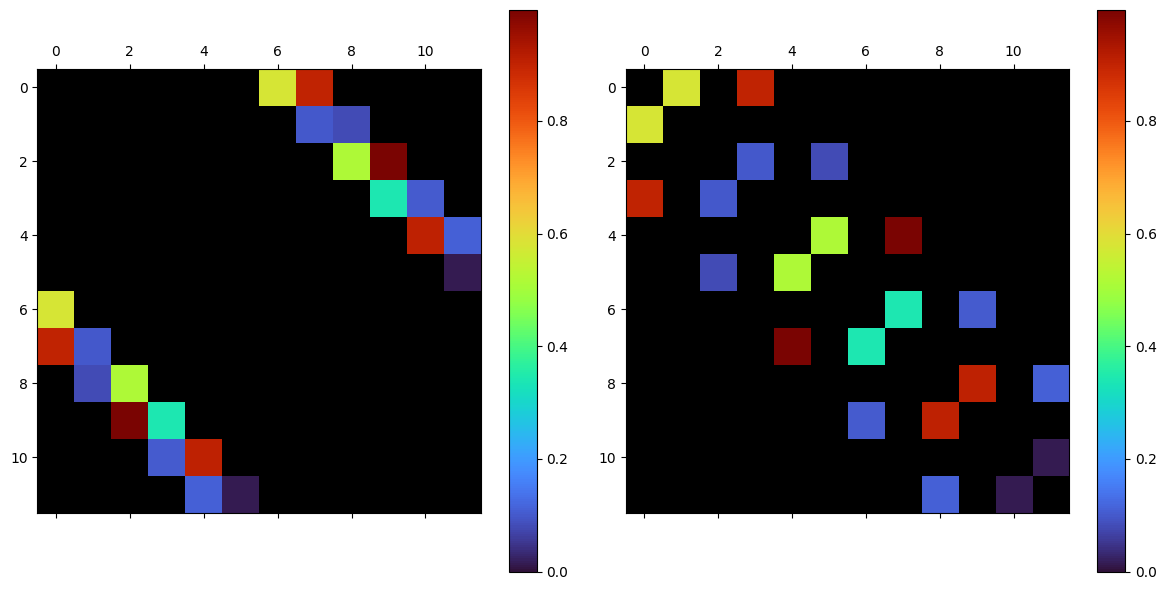

In [8]:
plot_matrices([A, P @ A @ P.T], (1, 2), (12, 6))

# P1.3.9

In [9]:
# Prepare data
r = 5
A_list = []
N = 1
for i in range(r):
    n = np.random.randint(1, 10)
    N *= n
    A_list.append(np.random.rand(n, n))
x = np.random.rand(N)


In [10]:
def kronecker_mul_slow(A_list, x):
    r = len(A_list)
    B = A_list[0]
    for i in range(1, r):
        B = np.kron(A_list[i], B)
    return B @ x

def kronecker_mul_fast(A_list, x):
    N = np.prod([A.shape[0] for A in A_list])
    r = len(A_list)

    def dfs(k, x, mk):
        if k == 0:
            return A_list[k] @ x   
        nk = A_list[k].shape[0]
        mk_next = mk // nk
        Y = np.empty((mk_next, nk))
        for i in range(0, nk):
            a1 = i * mk_next
            a2 = a1 + mk_next
            Y[:,i] = dfs(k - 1, x[a1:a2], mk_next)
        return np.reshape(Y @ A_list[k].T, (mk,), order='F')

    return dfs(r - 1, x, N)
    

In [11]:
y_correct = kronecker_mul_slow(A_list, x)
y = kronecker_mul_fast(A_list, x)

print(np.allclose(y_correct, y))

True


In [12]:
%timeit -r 2 -n 5 kronecker_mul_slow(A_list, x)
%timeit -r 2 -n 5 kronecker_mul_fast(A_list, x)


1.79 ms ± 48.5 μs per loop (mean ± std. dev. of 2 runs, 5 loops each)
316 μs ± 29.1 μs per loop (mean ± std. dev. of 2 runs, 5 loops each)


# P1.3.12

In [19]:
def strassen_matmul_handle_square(A, B, n_min):
    n = A.shape[0]

    if n <= n_min:
        return A @ B
    
    # Pad 
    pad = n % 2
    A = np.pad(A, ((0,pad),(0,pad)))
    B = np.pad(B, ((0,pad),(0,pad)))

    m = (n + pad) // 2
    u = slice(0, m)
    v = slice(m, n+pad)
    P1 = strassen_matmul_handle_square(A[u, u] + A[v, v], B[u, u] + B[v, v], n_min)
    P2 = strassen_matmul_handle_square(A[v, u] + A[v, v], B[u, u], n_min)
    P3 = strassen_matmul_handle_square(A[u, u], B[u, v] - B[v, v], n_min)
    P4 = strassen_matmul_handle_square(A[v, v], B[v, u] - B[u, u], n_min)
    P5 = strassen_matmul_handle_square(A[u, u] + A[u, v], B[v, v], n_min)
    P6 = strassen_matmul_handle_square(A[v, u] - A[u, u], B[u, u] + B[u, v], n_min)
    P7 = strassen_matmul_handle_square(A[u, v] - A[v, v], B[v, u] + B[v, v], n_min)
    C = np.empty((n+pad, n+pad))
    C[u, u] = P1 + P4 - P5 + P7
    C[u, v] = P3 + P5
    C[v, u] = P2 + P4
    C[v, v] = P1 + P3 - P2 + P6
    
    return C[0:n,0:n]

n = 1000
A = np.random.rand(n, n)
B = np.random.rand(n, n)
C_ref = A @ B
C = strassen_matmul_handle_square(A, B, 100)

# Check results
print(np.allclose(C, C_ref))



True


# P1.3.13


### Method 1: augment matrices to become square matrices

In [31]:
def strassen_matmul_handle_rect_padding(A, B, n_min):
    m, r = A.shape
    r1, n = B.shape
    assert r == r1

    max_dim = max(m, n, r)
    pad_m = max_dim - m
    pad_n = max_dim - n
    pad_r = max_dim - r

    A = np.pad(A, ((0, pad_m), (0, pad_r)))
    B = np.pad(B, ((0, pad_r), (0, pad_n)))
    C = strassen_matmul_handle_square(A, B, n_min)

    return C[0:m,0:n]

# Test
m, n, r = 1000, 1999, 599
A = np.random.rand(m, r)
B = np.random.rand(r, n)
C_ref = A @ B
C = strassen_matmul_handle_rect_padding(A, B, 100)

# Check results
print(np.allclose(C, C_ref))

True
